# CBF validation — isolated target-visibility test

**Goal.** Validate the `cbf2` target-visibility CBF *as a standalone safety filter*, decoupled from the
(currently untuned) PLASMC controller. Contract under test:

> given a **`theta_unsafe`** (a desired body tilt that would push the target off the camera sensor), the
> CBF must return a **`theta_safe`** that keeps the target **visible**, staying as close to `theta_unsafe`
> as the FoV allows (minimal intervention).

This runs the **exact live filter** (`src/cbf_visibility.cbf2_filter`) against an independent pinhole +
attitude camera model — the marker geometry is ground truth, nothing depends on the controller being
tuned. We compare **CBF** vs **no CBF** on the same `theta_unsafe`.

Plots: (1) **`theta_unsafe` vs `theta_safe` evolution** · (2) feature on the sensor vs the FoV box ·
(3) barrier `h`. The same plots regenerate from **real SITL logs** in the last section.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
from cbf_visibility import cbf2_filter        # the EXACT live filter

CENTER = np.array([320.0, 240.0]); FOCAL = np.array([270.0, 270.0])
P10    = CENTER / FOCAL                        # phi_max (tangent half-FoV) ~ [1.185, 0.889]
THETA_CAP = np.deg2rad(60.0); G = 9.81
M = np.array([[0.0, 1.0], [-1.0, 0.0]])       # lean-direction -> rotation-axis (a lean +x is a rotation about +y)
print("phi_max (tangent):", np.round(P10, 3), " theta_cap:", round(np.degrees(THETA_CAP)), "deg")

phi_max (tangent): [1.185 0.889]  theta_cap: 60 deg


## 1. Independent camera + attitude model (ground truth)
Downward pinhole projection (marker on the ground -> tangent feature), the rotational interaction matrix
`L_w`, the tilt->feature coupling `L_eff = L_w @ M`, and `R_from_image_tilt` (realize an attitude whose
controller-extracted image tilt equals a target). The CBF never sees these — only the corner pixels.

In [2]:
def Rx(a): c,s=np.cos(a),np.sin(a); return np.array([[1,0,0],[0,c,-s],[0,s,c]])
def Ry(a): c,s=np.cos(a),np.sin(a); return np.array([[c,0,s],[0,1,0],[-s,0,c]])
def Rz(a): c,s=np.cos(a),np.sin(a); return np.array([[c,-s,0],[s,c,0],[0,0,1]])

def project_tangent(R, cam, P):
    # downward pinhole (optical axis = body +z) -> tangent (x,y)
    b = R.T @ (P - cam); return np.array([b[0]/b[2], b[1]/b[2]])

def corners_from_centroid(cr, half=(0.04, 0.04)):
    # 4 raw-pixel corners with mean tangent == cr (matches img_node._feature_pts[-1][1])
    hx, hy = half
    t = np.array([[cr[0]-hx,cr[1]-hy],[cr[0]+hx,cr[1]-hy],[cr[0]+hx,cr[1]+hy],[cr[0]-hx,cr[1]+hy]])
    return CENTER + FOCAL * t

def L_eff(cr):
    x, y = cr
    Lw = np.array([[x*y, -(1+x*x)], [1+y*y, -x*y]])
    return Lw @ M                                # tilt -> feature coupling

def th_curr_of(R, yaw):
    return Rz(-yaw)[:2,:2] @ (-R[:2,2] / max(abs(R[2,2]), 1e-9))

def R_from_image_tilt(th, yaw):
    # body attitude whose extracted image-tilt == th (small-angle seed, Newton-refined)
    pitch, roll = -th[0], th[1]
    for _ in range(60):
        R = Rz(yaw) @ Ry(pitch) @ Rx(roll)
        e = th - th_curr_of(R, yaw)
        if np.linalg.norm(e) < 1e-13: break
        pitch += -e[0]; roll += e[1]
    return Rz(yaw) @ Ry(pitch) @ Rx(roll)

## 2. Scenario + the adversarial `theta_unsafe` schedule
The drone hovers level (`theta_curr = 0`); the marker sits **near the +x FoV edge** (`cr0 = [0.9, 0.2]`)
because of where the drone is. An outer controller demands `theta_unsafe`: a lean toward that edge that
ramps up, holds, releases. Each `theta_unsafe` is filtered **independently** (single-step, the regime the
one-step CBF guarantees) — a clean characterization, not a confounded closed loop.

In [3]:
YAW = 0.4                                    # nonzero -> exercises the Rz(+/-yaw) maps
Z = 4.0; CAM = np.array([0.0, 0.0, -Z])
cr0 = np.array([0.90, 0.20])                  # marker near the +x edge (phi_max_x = 1.185) at level
P_MARKER = np.zeros(3); P_MARKER[:2] = Z * (Rz(YAW)[:2,:2] @ cr0)
R0 = R_from_image_tilt(np.zeros(2), YAW)      # level attitude
assert np.allclose(project_tangent(R0, CAM, P_MARKER), cr0, atol=1e-6)

T = 240; t = np.arange(T) * (1/60.0)
mag = np.concatenate([np.linspace(0, 0.85, 150), np.full(50, 0.85), np.linspace(0.85, 0, 40)])
DIR = np.array([1.0, 0.25]); DIR = DIR / np.linalg.norm(DIR)
theta_unsafe = mag[:, None] * DIR[None, :]    # (T,2) desired image-axis lean
print(f"marker at cr0={cr0}, phi_max={np.round(P10,3)};  theta_unsafe peak={mag.max():.2f} rad "
      f"= {round(np.degrees(mag.max()))} deg")

marker at cr0=[0.9 0.2], phi_max=[1.185 0.889];  theta_unsafe peak=0.85 rad = 49 deg


## 3. Filter each `theta_unsafe` through the CBF
For each step: form the desired accel from `theta_unsafe`, call `cbf2_filter` (level attitude, marker at
`cr0`), read `theta_safe`. We evaluate the **predicted feature** (the QP's guarantee, `cr0 + L_eff*theta`)
and the **true feature** (full projection at that tilt) for CBF vs no-CBF.

In [4]:
def filt():
    th_safe, state = [], {}
    for k in range(T):
        a_xy = G * (Rz(YAW)[:2,:2] @ theta_unsafe[k]); I_a = np.array([a_xy[0], a_xy[1], -G])
        _, _, ok, ts = cbf2_filter(I_a.copy(), R0, R0[2,2], YAW, corners_from_centroid(cr0),
                                   CENTER, FOCAL, P10, THETA_CAP, 0.0, None, np.zeros(2), state)
        th_safe.append(ts if ts is not None else Rz(-YAW)[:2,:2] @ (I_a[:2]/G))
    return np.array(th_safe)

th_cbf = filt()
Le = L_eff(cr0)
def predict(TH): return cr0[None,:] + (Le @ TH.T).T          # first-order feature under tilt TH
def truefeat(TH): return np.array([project_tangent(R_from_image_tilt(th, YAW), CAM, P_MARKER) for th in TH])

series = {
    "CBF":    dict(th=th_cbf,       pred=predict(th_cbf),       true=truefeat(th_cbf),       c="b"),
    "no-CBF": dict(th=theta_unsafe, pred=predict(theta_unsafe), true=truefeat(theta_unsafe), c="r"),
}
print(f"{'config':8} {'th_safe_x peak':>14} {'pred-in-box':>12} {'max|cr_x| true':>15}")
for nm, s in series.items():
    pin = np.all(np.abs(s["pred"]) <= P10[None,:] + 1e-9, axis=1).mean()
    print(f"{nm:8} {s['th'][:,0].max():>14.3f} {pin:>12.2f} {np.abs(s['true'][:,0]).max():>15.3f}")

config   th_safe_x peak  pred-in-box  max|cr_x| true
CBF               0.154         1.00           1.250
no-CBF            0.825         0.15           8.062


## 4. Plot 1 — `theta_unsafe` vs `theta_safe` (the requested plot)
The CBF passes the desired tilt through while safe, then **saturates the offending x-component** once the
predicted feature reaches the FoV edge — minimal intervention plus a hard wall.

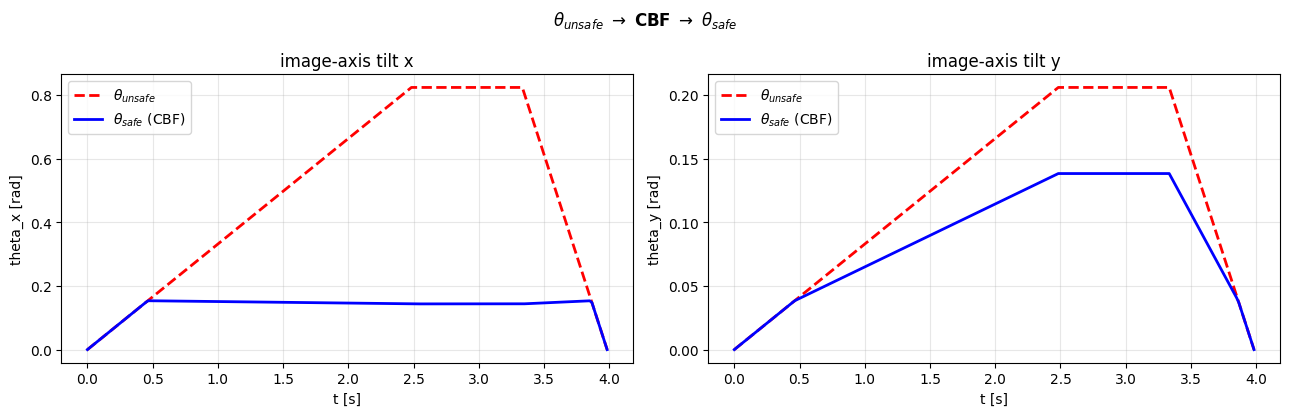

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for j, axis in enumerate("xy"):
    ax[j].plot(t, theta_unsafe[:, j], 'r--', lw=2, label=r"$\theta_{unsafe}$")
    ax[j].plot(t, th_cbf[:, j], 'b-', lw=2, label=r"$\theta_{safe}$ (CBF)")
    ax[j].set_title(f"image-axis tilt {axis}"); ax[j].set_xlabel("t [s]")
    ax[j].set_ylabel(f"theta_{axis} [rad]"); ax[j].legend(); ax[j].grid(alpha=0.3)
fig.suptitle(r"$\theta_{unsafe}\ \to\ $CBF$\ \to\ \theta_{safe}$", fontweight='bold')
fig.tight_layout(); plt.show()

## 5. Plot 2 — feature on the sensor vs the FoV box
Predicted feature (QP guarantee, solid) and true feature (projection, faint). **The CBF holds the
predicted feature exactly on the FoV edge** (true feature within the one-step linearization margin);
without it the feature runs far off the sensor.

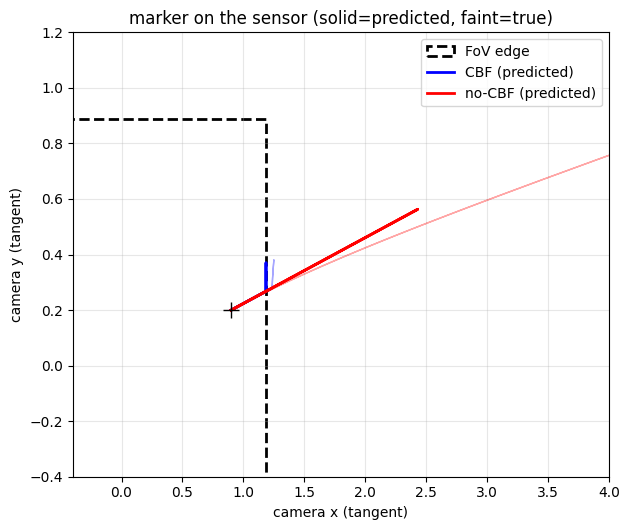

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.add_patch(plt.Rectangle((-P10[0],-P10[1]), 2*P10[0], 2*P10[1], fill=False, ec='k', lw=2, ls='--',
                           label="FoV edge"))
for nm, s in series.items():
    ax.plot(s["pred"][:,0], s["pred"][:,1], '-', color=s["c"], lw=2,  label=f"{nm} (predicted)")
    ax.plot(s["true"][:,0], s["true"][:,1], '-', color=s["c"], lw=1, alpha=0.35)
ax.plot(*cr0, 'k+', ms=11); ax.set_xlim(-0.4, 4.0); ax.set_ylim(-0.4, 1.2)
ax.set_xlabel("camera x (tangent)"); ax.set_ylabel("camera y (tangent)")
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
ax.set_title("marker on the sensor (solid=predicted, faint=true)"); plt.tight_layout(); plt.show()

## 6. Plot 3 — barrier `h = min_k(phi_max - |feature_k|)` (predicted)
`h >= 0` ⇔ target on the sensor. The CBF holds `h ≈ 0` (rides the edge); without it `h` goes negative
(target off-sensor).

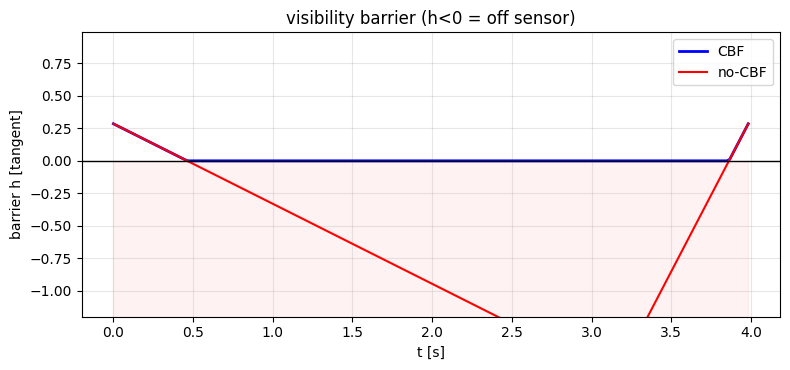

In [7]:
plt.figure(figsize=(8, 3.8))
for nm, s in series.items():
    h = np.min(P10[None,:] - np.abs(s["pred"]), axis=1)
    plt.plot(t, h, '-', color=s["c"], lw=2 if nm=="CBF" else 1.5, label=nm)
plt.axhline(0, color='k', lw=1); plt.fill_between(t, -10, 0, color='red', alpha=0.05)
plt.ylim(-1.2, P10.min()+0.1); plt.xlabel("t [s]"); plt.ylabel("barrier h [tangent]")
plt.legend(); plt.grid(alpha=0.3); plt.title("visibility barrier (h<0 = off sensor)")
plt.tight_layout(); plt.show()

## 7. Verdict (offline isolated)
If **CBF** shows **pred-in-box ≈ 1.0** and a much smaller `max|cr_x| true` than **no-CBF**, the filter
satisfies its contract: it turns an unsafe tilt into a safe one that keeps the target on the sensor, with
minimal intervention while safe. The residual true-feature overshoot near the edge is the known
**one-step linearization** margin — in flight the barrier re-evaluates every frame (receding horizon),
which the SITL test below exercises.

## 8. Real SITL logs — CBF understanding plots
`apps/cbf_isolation_test.py` flies the drone under **stock PX4 attitude control**, generates a
`theta_unsafe` schedule, filters it through `cbf2_filter`, commands `theta_safe`, and logs everything.
The cells below auto-load the latest run (set `RUN_DIR` to pick one) and derive the diagnostics, then
plot: `theta_unsafe` vs `theta_safe`; **intervention** `‖θ_safe−θ_unsafe‖` with the barrier `h`;
**barrier** `h(t)`; **per-axis margin** (which FoV edge binds); **commanded vs achieved tilt**
(does PX4 track the setpoint?); and **predicted vs measured feature** (one-step linearization fidelity).

In [8]:
import glob
RUN_DIR = None     # e.g. "../test_data/CBF_Isolation/<ts>_cbf"; None -> latest CBF-on run
runs = (sorted(glob.glob("../test_data/CBF_Isolation/*_cbf/CBF_Isolation.npy"))
        or sorted(glob.glob("../test_data/CBF_Isolation/*/CBF_Isolation.npy")))
path = (os.path.join(RUN_DIR, "CBF_Isolation.npy") if RUN_DIR else (runs[-1] if runs else None))
HAVE_SITL = path is not None and os.path.exists(path)
if not HAVE_SITL:
    print("No SITL run yet — run apps/cbf_isolation_test.py "
          "(PY_SCRIPT=apps/cbf_isolation_test.py bash scripts/run_aruco_landing.sh).")
else:
    d = np.load(path, allow_pickle=True).item(); meta = d["meta"]
    ts  = np.asarray(d["t"]); thu = np.asarray(d["theta_unsafe"]); ths = np.asarray(d["theta_safe"])
    cor = np.asarray(d["corners"]); cen = np.asarray(meta["center"]); foc = np.asarray(meta["focal"])
    quat = np.asarray(d["quat"]); P10s = cen / foc
    cr  = (np.nanmean(cor, axis=1) - cen) / foc          # measured centroid (tangent)

    def quat_to_R(q):                                    # body->inertial DCM
        w,x,y,z = q
        return np.array([[1-2*(y*y+z*z), 2*(x*y-w*z), 2*(x*z+w*y)],
                         [2*(x*y+w*z), 1-2*(x*x+z*z), 2*(y*z-w*x)],
                         [2*(x*z-w*y), 2*(y*z+w*x), 1-2*(x*x+y*y)]])
    Rs   = [quat_to_R(q) for q in quat]
    yaws = np.array([np.arctan2(R[1,0], R[0,0]) for R in Rs])
    th_ach = np.array([th_curr_of(Rs[i], yaws[i]) for i in range(len(Rs))])   # ACHIEVED image-tilt
    interv = np.linalg.norm(ths - thu, axis=1)                                # CBF intervention
    h_meas = np.nanmin(P10s[None,:] - np.abs(cr), axis=1)                     # barrier h
    mx = P10s[0] - np.abs(cr[:,0]); my = P10s[1] - np.abs(cr[:,1])            # per-axis margin
    cr_pred = np.array([cr[k] + L_eff(cr[k]) @ (ths[k] - th_ach[k]) for k in range(len(ts))])
    cbf_on = bool(meta["cbf_on"])
    print(f"loaded {os.path.basename(os.path.dirname(path))}  CBF {'ON' if cbf_on else 'OFF'}  "
          f"{len(ts)} samples, {ts[-1]-ts[0]:.1f}s; marker-in-FoV "
          f"{np.all(np.abs(cr) <= P10s[None,:], axis=1).mean()*100:.0f}%")

loaded 20260614-133310_cbf  CBF ON  315 samples, 12.8s; marker-in-FoV 100%


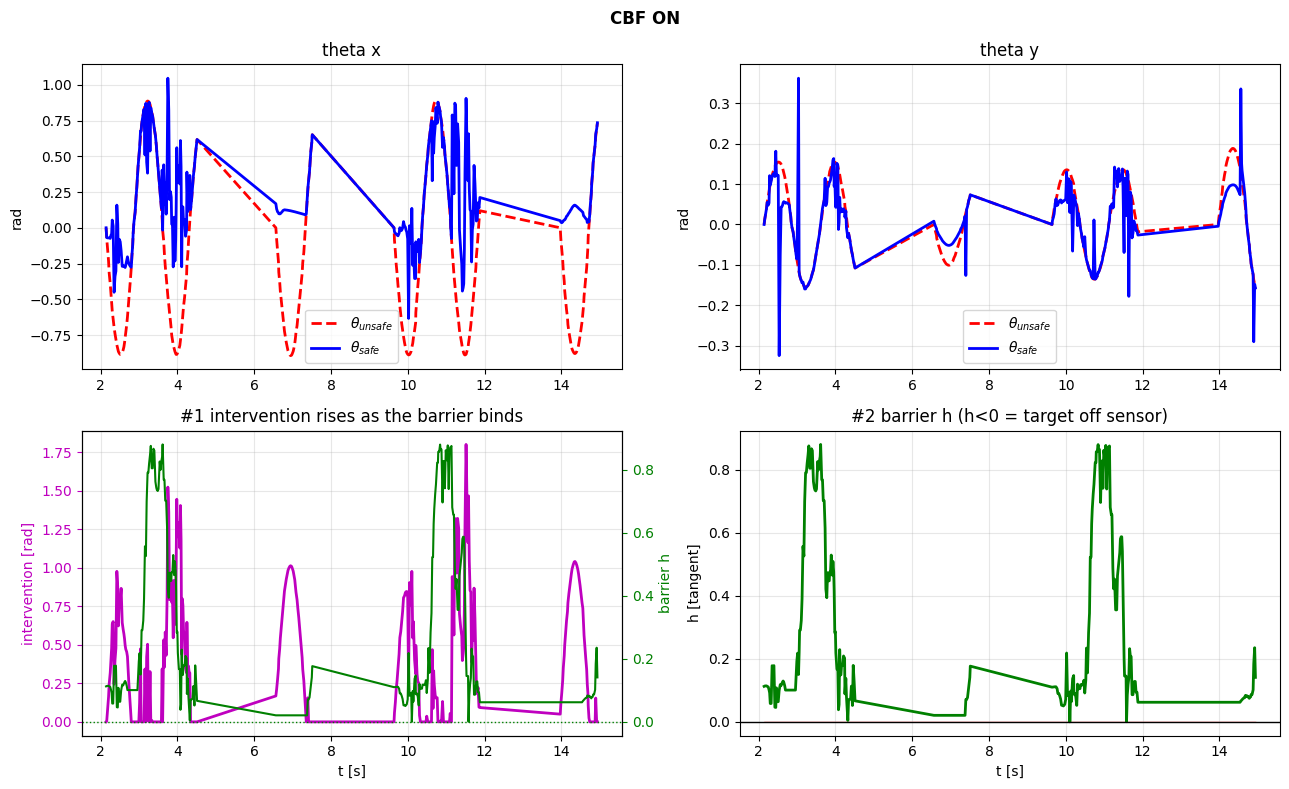

In [9]:
if HAVE_SITL:
    fig, ax = plt.subplots(2, 2, figsize=(13, 8))
    # theta_unsafe vs theta_safe (x,y)
    for j, axis in enumerate("xy"):
        ax[0,j].plot(ts, thu[:,j], 'r--', lw=2, label=r"$\theta_{unsafe}$")
        ax[0,j].plot(ts, ths[:,j], 'b-', lw=2, label=r"$\theta_{safe}$")
        ax[0,j].set_title(f"theta {axis}"); ax[0,j].set_ylabel("rad"); ax[0,j].legend(); ax[0,j].grid(alpha=0.3)
    # (#1) intervention + barrier h on a twin axis
    a = ax[1,0]; a.plot(ts, interv, 'm-', lw=2, label=r"$\|\theta_{safe}-\theta_{unsafe}\|$")
    a.set_ylabel("intervention [rad]", color='m'); a.tick_params(axis='y', colors='m'); a.grid(alpha=0.3)
    a2 = a.twinx(); a2.plot(ts, h_meas, 'g-', lw=1.5, label="h"); a2.axhline(0, color='g', ls=':', lw=1)
    a2.set_ylabel("barrier h", color='g'); a2.tick_params(axis='y', colors='g')
    a.set_title("#1 intervention rises as the barrier binds"); a.set_xlabel("t [s]")
    # (#2) barrier h standalone with the unsafe region shaded
    b = ax[1,1]; b.plot(ts, h_meas, 'g-', lw=2); b.axhline(0, color='k', lw=1)
    b.fill_between(ts, np.minimum(h_meas, 0), 0, color='red', alpha=0.2)
    b.set_title("#2 barrier h (h<0 = target off sensor)"); b.set_xlabel("t [s]"); b.set_ylabel("h [tangent]"); b.grid(alpha=0.3)
    fig.suptitle(f"CBF {'ON' if cbf_on else 'OFF'}", fontweight='bold'); fig.tight_layout(); plt.show()

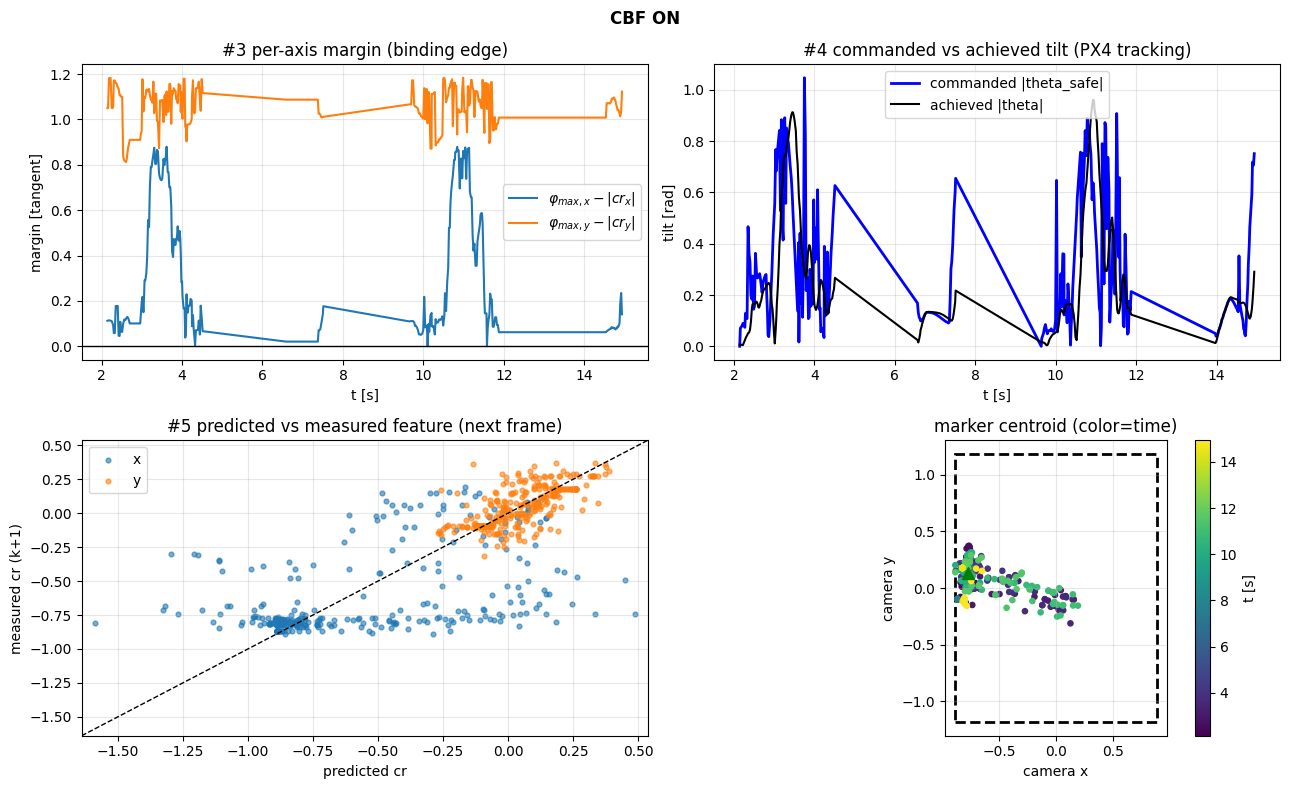

In [10]:
if HAVE_SITL:
    fig, ax = plt.subplots(2, 2, figsize=(13, 8))
    # (#3) per-axis margin: which FoV edge binds
    ax[0,0].plot(ts, mx, label=r"$\varphi_{max,x}-|cr_x|$")
    ax[0,0].plot(ts, my, label=r"$\varphi_{max,y}-|cr_y|$")
    ax[0,0].axhline(0, color='k', lw=1); ax[0,0].set_title("#3 per-axis margin (binding edge)")
    ax[0,0].set_xlabel("t [s]"); ax[0,0].set_ylabel("margin [tangent]"); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)
    # (#4) commanded vs achieved tilt (does PX4 track theta_safe?)
    ax[0,1].plot(ts, np.linalg.norm(ths, axis=1), 'b-', lw=2, label="commanded |theta_safe|")
    ax[0,1].plot(ts, np.linalg.norm(th_ach, axis=1), 'k-', lw=1.5, label="achieved |theta|")
    ax[0,1].set_title("#4 commanded vs achieved tilt (PX4 tracking)")
    ax[0,1].set_xlabel("t [s]"); ax[0,1].set_ylabel("tilt [rad]"); ax[0,1].legend(); ax[0,1].grid(alpha=0.3)
    # (#5) predicted vs measured feature (one-step linearization fidelity)
    ax[1,0].scatter(cr_pred[:-1,0], cr[1:,0], s=12, alpha=0.6, label="x")
    ax[1,0].scatter(cr_pred[:-1,1], cr[1:,1], s=12, alpha=0.6, label="y")
    lim = [min(cr.min(), cr_pred.min())-0.05, max(cr.max(), cr_pred.max())+0.05]
    ax[1,0].plot(lim, lim, 'k--', lw=1); ax[1,0].set_xlim(lim); ax[1,0].set_ylim(lim)
    ax[1,0].set_title("#5 predicted vs measured feature (next frame)")
    ax[1,0].set_xlabel("predicted cr"); ax[1,0].set_ylabel("measured cr (k+1)"); ax[1,0].legend(); ax[1,0].grid(alpha=0.3)
    # measured centroid on the sensor vs the FoV box
    c = ax[1,1]; c.add_patch(plt.Rectangle((-P10s[0],-P10s[1]), 2*P10s[0], 2*P10s[1], fill=False, ec='k', lw=2, ls='--'))
    sc = c.scatter(cr[:,0], cr[:,1], c=ts, cmap='viridis', s=14); c.plot(cr[0,0], cr[0,1], 'g^', ms=9)
    c.set_aspect('equal'); c.set_title("marker centroid (color=time)"); c.set_xlabel("camera x"); c.set_ylabel("camera y"); c.grid(alpha=0.3)
    fig.colorbar(sc, ax=c, label="t [s]"); fig.suptitle(f"CBF {'ON' if cbf_on else 'OFF'}", fontweight='bold')
    fig.tight_layout(); plt.show()